# <h2 align="center">**Project 2 - Image Processing** </h2>

##### **Import Library**

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

##### **1. Adjust Brightness**

In [2]:
def adjust_brightness(image, brightness): 
    image = image + float(brightness)
    image = np.clip(image, 0, 255) 
    return np.uint8(image)

def show_brightened_image(image, image_str):
    brightness = input("Enter brightness [-255,255]: ")
    result = adjust_brightness(image, brightness)
    plt.imshow(result)
    
    output = image_str.split('.')[0] + '_brightness' + '.png'
    Image.fromarray(result).save(output)

##### **2. Adjust contrast**

In [3]:
def adjust_contrast(image, contrast):
    f = (259 * (255 + contrast)) / (255 * (259 - contrast))
    image = image * float(f) - 128 * float(f) + 128
    image = np.clip(image, 0 ,255)
    
    return np.uint8(image)

def show_contrast_image(image, image_str):
    contrast = input("Enter contrast [-255,255]: ")
    contrast = int(contrast)
    result = adjust_contrast(image, contrast)
    plt.imshow(result)
    
    output = image_str.split('.')[0] + '_contrast' + '.png'
    Image.fromarray(result).save(output)

##### **3. Flip the image (Vertical / Horizontal)**

In [4]:
def flip_image(image, direction):
    if direction == 'vertical':
        return np.flipud(image)
    elif direction == 'horizontal':
        return np.fliplr(image)

def show_flipped_image(image, image_str):
    print("""
    1. Vertical
    2. Horizontal
    """)
    direction = input("Enter direction: ")
    
    if direction == '1':
        direction = 'vertical'
        
    if direction == '2':
        direction = 'horizontal'
        
    result = flip_image(image, direction)
    plt.imshow(result)

    output = image_str.split('.')[0] + '_flip_' + direction + '.png'
    Image.fromarray(result).save(output)

##### **4. Convert RGB image to grayscale image**

In [5]:
def convert_to_grayscale_image(image):
    weight = np.array([0.3, 0.59, 0.11])
    image = image @ weight 
    return np.uint8(image)

def show_grayscale_image(image, image_str):
    result = convert_to_grayscale_image(image)
    plt.imshow(result)
    
    output = image_str.split('.')[0] + '_grayscale' + '.png'
    Image.fromarray(result).save(output)


##### **5. Blur/Sharpen the image**

In [6]:
def blur_image(image):
    # Gaussian blur 3x3 
    kernel = np.array([[[1], [2], [1]],
                       [[2], [4], [2]],
                       [[1], [2], [1]]]) / 16
    
    # add padding
    padding_matrix = np.zeros((image.shape[0] + 2, image.shape[1] + 2, image.shape[2]))
    padding_matrix[1:-1,1:-1,:] = image
    
    for col in range(0, image.shape[0]):
        for row in range(0, image.shape[1]):
            image[col][row] = (padding_matrix[col:col+3, row:row+3] * kernel).sum(axis=1).sum(axis=0)
            
    return np.uint8(image)

def sharpen_image(image):
    kernel = np.array([[[0], [-1], [0]],
                       [[-1], [5], [-1]],
                       [[0], [-1], [0]]])
    
    # add padding
    padding_matrix = np.zeros((image.shape[0] + 2, image.shape[1] + 2, image.shape[2]))
    padding_matrix[1:-1,1:-1,:] = image
    
    for col in range(0, image.shape[0]):
        for row in range(0, image.shape[1]):
            image[col][row] = (padding_matrix[col:col+3, row:row+3] * kernel).sum(axis=1).sum(axis=0)
            
    return np.uint8(image)

def show_blurred_image(image, image_str):
    result = blur_image(image)
    plt.imshow(result)
    
    output = image_str.split('.')[0] + '_blur' + '.png'
    Image.fromarray(result).save(output)
    
def show_sharpened_image(image, image_str):
    result = sharpen_image(image)
    plt.imshow(result)
    
    output = image_str.split('.')[0] + '_sharpen' + '.png'
    Image.fromarray(result).save(output)
    
def show_blurred_sharpened_image(image, image_str):
    print("""
    1. Blur
    2. Sharpen
    """)
    type = input("Enter type: ")
    
    if type == '1':
        show_blurred_image(image, image_str)
        
    if type == '2':
        show_sharpened_image(image, image_str)
        

##### **6. Circular mask**

In [7]:
def circular_mask(height, width):
    center = (int(width/2), int(height/2))
    radius = min(center[0], center[1], width-center[0], height-center[1])

    y, x = np.ogrid[:height, :width]
    mask = np.sqrt((x - center[0])**2 + (y-center[1])**2) <= radius
    
    return mask


def show_circular_mask(image):
    mask = circular_mask(image.shape[0], image.shape[1])
    image[~mask] = 0
    plt.imshow(image)
    
    output = 'corgi_circular_mask.png'
    Image.fromarray(image).save(output)
    


#### **Hàm main()**

Enter the image name: 

    Image Processing
    0. All
    1. Adjust brightness
    2. Adjust contrast
    3. Flip image (vertical or horizontal)
    4. Convert to grayscale 
    5. Blur/Sharpen image
    6. Circular mask
    7. Exit
    


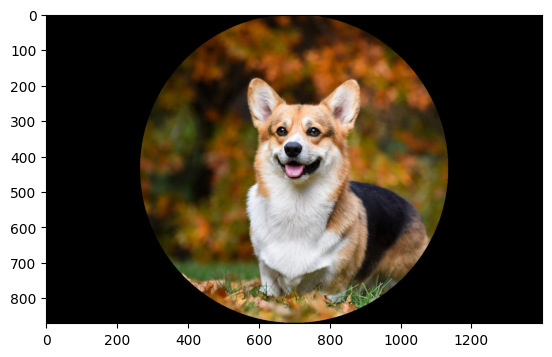

In [16]:
def main():
    print("Enter the image name: ")
    image_str = input() #'cat.jpg'
    #image_str = 'cat.jpg'
    
    image = Image.open(image_str)
    image = np.array(image)
 
    print("""
    Image Processing
    0. All
    1. Adjust brightness
    2. Adjust contrast
    3. Flip image (vertical or horizontal)
    4. Convert to grayscale 
    5. Blur/Sharpen image
    6. Circular mask
    7. Exit
    """)
    
    choice = input("Enter your choice: ")
    if choice == '0':
        print('Adjust brightness:')
        show_brightened_image(image, image_str)

        print('Adjust contrast:')
        show_contrast_image(image, image_str)

        print('Flip image (vertical or horizontal):')
        show_flipped_image(image, image_str)

        print('Convert to grayscale :')
        show_grayscale_image(image, image_str)

        print('Blur/Sharpen image:')
        show_blurred_sharpened_image(image, image_str)

        print('Circular mask:')
        show_circular_mask(image)

    elif choice == "1":
        show_brightened_image(image, image_str)

    elif choice == "2":
        show_contrast_image(image, image_str)

    elif choice =="3":
        show_flipped_image(image, image_str)

    elif choice  =="4":
       show_grayscale_image(image, image_str)

    elif choice  =="5":
        show_blurred_sharpened_image(image, image_str)

    elif choice  =="6":
        show_circular_mask(image)

    elif choice  =="7":
        print("\n Exit") 
        choice  = None
        
    else:
        print("\n Invalid choice")

main()
    